# 03 · Sampling — walking from noise back to data

We have a network that predicts the noise. Now we cash it in for actual samples.

> ### ✅ Solution notebook
> This is the answer key for `notebooks/` — every TODO is filled in. Try the
> exercise version first.


## 1. The algorithm

Everything follows from the boxed result of notebook 02: the mean of the reverse
step, expressed through the noise. Swap the true (unknown) $\varepsilon$ for our
network's prediction $\varepsilon_\theta(x_t,t)$:

$$\mu_\theta(x_t,t)=\frac{1}{\sqrt{\alpha_t}}\Big(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)\Big)$$

Then a full reverse step **draws a sample** from that Gaussian. Recall the reparameterization trick from notebook 01: sampling $y\sim\mathcal N(\mu,\sigma^2 I)$ is identical to computing $y=\mu+\sigma\,z$ with $z\sim\mathcal N(0,I)$ — all the randomness lives in the single standard draw $z$. Here $\mu=\mu_\theta$ and $\sigma^2=\tilde\beta_t$, so the abstract "draw $x_{t-1}$ from $p_\theta$" turns into one concrete, runnable line:

$$\boxed{\;x_{t-1}=\mu_\theta(x_t,t)+\sqrt{\tilde\beta_t}\;z,\qquad z\sim\mathcal N(0,I)\;}$$

**The complete sampling algorithm:**

1. draw $x_T\sim\mathcal N(0,I)$ — legitimate, because $\bar\alpha_T\approx 0$
2. for $t=T, T-1, \dots, 1$: predict $\varepsilon_\theta(x_t,t)$, form $\mu_\theta$,
   add $\sqrt{\tilde\beta_t}\,z$
3. at $t=0$, return $\mu_\theta$ with **no** noise added

That's it. It's called an **ancestral sampler** because we walk back down the chain
of ancestors $x_T \to x_{T-1}\to\dots\to x_0$.

## The anatomy of one reverse step

It's worth slowing down on the update itself. Expand $\mu_\theta$ and the full
step splits into three distinct moves:

$$x_{t-1}=\underbrace{\tfrac{1}{\sqrt{\alpha_t}}\,x_t}_{\text{(1) un-shrink}}\;-\;\underbrace{\tfrac{\beta_t}{\sqrt{\alpha_t}\,\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)}_{\text{(2) subtract predicted noise}}\;+\;\underbrace{\sqrt{\tilde\beta_t}\,z}_{\text{(3) re-inject a little noise}}$$

1. **Un-shrink.** The forward step multiplied the signal by $\sqrt{\alpha_t}$;
   dividing by it undoes that shrink, scaling $x_t$ back up.
2. **Subtract the predicted noise.** The network says "*this* is the noise in
   $x_t$" ($\varepsilon_\theta$); we remove a calibrated portion of it. We peel off
   only a fraction each step — which is exactly why we need many steps for the
   removals to accumulate into a clean sample.
3. **Re-inject noise.** Add back a small, fresh $\sqrt{\tilde\beta_t}\,z$ — the
   exploration term from §2, which keeps the output a *sample* rather than an
   average.

Moves (1)+(2) are the deterministic "denoise a little" push (that's $\mu_\theta$);
move (3) is the stochastic kick.

### Why this looks like Langevin dynamics (a peek at notebook 07)

There's a deeper reading of move (2). The predicted noise is, up to a constant, an
estimate of the **score** — the gradient of the log-density that points toward
where data is dense:

$$\nabla_{x}\log q(x_t)\;\approx\;-\frac{\varepsilon_\theta(x_t,t)}{\sqrt{1-\bar\alpha_t}}.$$

So "subtract the predicted noise" is really "**take a small step uphill, toward
more-likely data**," and "add fresh noise" (move 3) is the random kick of
**Langevin dynamics** — the classic recipe for sampling a distribution you only
know through its score. The DDPM reverse step *is* a discretized, annealed Langevin
sampler; notebook 07 makes this precise.

<details>
<summary><b>▸ Where the reverse mean comes from: "predict x₀" and "predict the noise" are the same step</b></summary>

Two recipes that look different give the *same* update.

**Recipe A — predict the clean image, then take the posterior mean.** From the nice
property, an estimate of $x_0$ falls straight out of the predicted noise:

$$\hat x_0=\frac{x_t-\sqrt{1-\bar\alpha_t}\,\varepsilon_\theta}{\sqrt{\bar\alpha_t}}.$$

Feed $\hat x_0$ into the §2 posterior mean $\tilde\mu_t(x_t,\hat x_0)$:

$$\tilde\mu_t=\frac{\sqrt{\bar\alpha_{t-1}}\,\beta_t}{1-\bar\alpha_t}\,\hat x_0+\frac{\sqrt{\alpha_t}\,(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}\,x_t.$$

**Recipe B — predict the noise, take the collapsed step** (what we implement):

$$\mu_\theta=\frac{1}{\sqrt{\alpha_t}}\Big(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta\Big).$$

Substitute the $\hat x_0$ expression into Recipe A and simplify with the same two
identities as notebook 02 ($\alpha_t\bar\alpha_{t-1}=\bar\alpha_t$ and
$\alpha_t+\beta_t=1$): the $x_t$ coefficients add to $1/\sqrt{\alpha_t}$ and the
$\varepsilon_\theta$ coefficient to $-\beta_t/(\sqrt{\alpha_t}\sqrt{1-\bar\alpha_t})$
— **exactly Recipe B**. They're identical.

That's why the sampler needs only $\varepsilon_\theta$: predicting the noise and
predicting the clean image are linked by the invertible nice property, and either
leads to the same reverse mean. (One practical upside of Recipe A: you can **clip
$\hat x_0$** to a valid pixel range for a small quality gain — something the
collapsed form hides.)

</details>

## 2. Two questions worth asking

**Why add fresh noise $z$ at every step?** It feels backwards — we're trying to
*remove* noise! But remember what we're doing: **sampling from a distribution**,
not finding a single best answer. The network's $\mu_\theta$ is only the *centre*
of the plausible $x_{t-1}$'s; the $\sqrt{\tilde\beta_t}z$ term explores that
spread. Drop it and every run from the same $x_T$ collapses toward one averaged,
over-smoothed outcome, losing diversity. (There *is* a principled way to remove the
noise and stay sharp — that's DDIM, notebook 05.)

**Why no noise on the final step?** After the $t=1\to 0$ step we want to *output*
a clean sample, not one more noisy draw. So we return the mean — our best estimate
of the clean data. Adding noise there would just smear visible grain over the
result.

**What variance to use?** We use the true posterior variance from notebook 02,
$\tilde\beta_t=\beta_t\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}$. Note it goes to
0 as $t\to0$, which is consistent with taking no noise on the last step. (DDPM
found plain $\beta_t$ works about as well.)

In [1]:
import torch
import matplotlib.pyplot as plt

from nanodiffusion.utils import pick_device, set_seed, scatter_2d
from nanodiffusion.data import toy2d
from nanodiffusion.schedules import NoiseSchedule
from nanodiffusion.models import MLPDenoiser
from nanodiffusion.objectives import ddpm_eps_loss
from nanodiffusion.samplers import ddpm_sample as reference_sample   # for the self-check

set_seed(0)
device = pick_device()
schedule = NoiseSchedule.make("cosine", 200).to(device)
data = toy2d("swiss_roll", 8000).to(device)
print("device:", device)

device: mps


### Get a trained model

We reuse the reference denoiser here so this notebook's TODO stays focused purely
on the **sampler**. Trains in a few seconds.

In [2]:
set_seed(0)
model = MLPDenoiser().to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
for step in range(2000):
    idx = torch.randint(0, data.shape[0], (512,), device=device)
    loss = ddpm_eps_loss(model, data[idx], schedule)
    opt.zero_grad(); loss.backward(); opt.step()
model.eval()
print(f"trained, final loss {loss.item():.4f}")

trained, final loss 0.3859


## TODO — the ancestral sampler

Implement the boxed reverse step. Available on `schedule` (length-$T$ tensors,
already on the right device):

`schedule.betas` · `schedule.alphas` · `schedule.alpha_bars` ·
`schedule.alpha_bars_prev` · `schedule.sqrt_one_minus_alpha_bars`

Here we index with `[step]` (a plain int), giving a scalar per timestep — the
whole batch is at the same $t$, so no reshaping is needed.

In [3]:
@torch.no_grad()
def my_ddpm_sample(model, schedule, shape, device, return_trajectory=False):
    '''Reverse the diffusion process: pure noise -> data.'''
    x = torch.randn(shape, device=device)        # start from x_T ~ N(0, I)
    traj = [x.clone()]

    for step in reversed(range(schedule.timesteps)):
        t = torch.full((shape[0],), step, device=device, dtype=torch.long)
        eps = model(x, t)                         # predicted noise

        beta_t = schedule.betas[step]
        alpha_t = schedule.alphas[step]
        sqrt_1m_ab = schedule.sqrt_one_minus_alpha_bars[step]

        mean = (x - beta_t / sqrt_1m_ab * eps) / torch.sqrt(alpha_t)

        if step > 0:
            posterior_var = (beta_t * (1 - schedule.alpha_bars_prev[step])
                             / (1 - schedule.alpha_bars[step]))
            x = mean + torch.sqrt(posterior_var) * torch.randn_like(x)
        else:
            x = mean          # final step: no noise, return the clean estimate

        if return_trajectory:
            traj.append(x.clone())

    return (x, traj) if return_trajectory else x

In [4]:
# ---- self-check ----
# Same seed + same model => your sampler should match the reference step for step.
set_seed(123); mine = my_ddpm_sample(model, schedule, (2000, 2), device)
set_seed(123); ref = reference_sample(model, schedule, (2000, 2), device=device)
assert mine.shape == (2000, 2), f"shape {tuple(mine.shape)} != (2000, 2)"
assert torch.isfinite(mine).all(), "produced NaN/inf — check the mean formula"
assert torch.allclose(mine, ref, atol=1e-4), "doesn't match the reference sampler"

# and the generated distribution should match the real one
real_std, gen_std = data.std(0).cpu(), mine.std(0).cpu()
print(f"real std {[round(v, 3) for v in real_std.tolist()]}")
print(f"gen  std {[round(v, 3) for v in gen_std.tolist()]}")
assert torch.allclose(gen_std, real_std, atol=0.25), "distribution doesn't match the data"
print("✅ sampler correct")

real std [0.974, 1.025]
gen  std [0.988, 1.011]
✅ sampler correct


## 3. Your samples

The real test is visual: does the generated cloud look like the same distribution?
These points were **never in the dataset** — the model invented them.

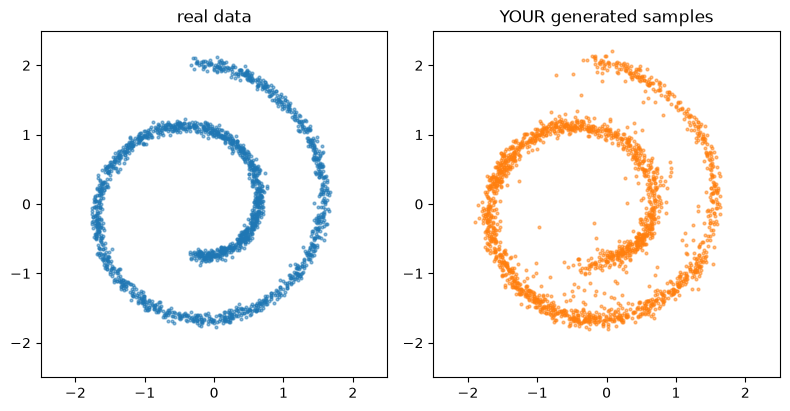

In [5]:
gen = my_ddpm_sample(model, schedule, (2000, 2), device)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 4))
scatter_2d(a1, data[:2000], "real data")
scatter_2d(a2, gen, "YOUR generated samples", color="C1")
plt.tight_layout(); plt.show()

> **🔬 Explore.** Run the sampling cell again — because each reverse step injects
> fresh noise (§2), every run produces a *different* valid cloud from the same
> trained model. Try `set_seed(1)` just before it to make a run reproducible, or
> bump `(2000, 2)` to generate more points. That variety is the whole point of a
> generative model: not one answer, but a distribution of them.

## 4. The reverse trajectory

Watch the noise blob reorganize into a spiral. Compare it with notebook 01's
forward plots — this is the same journey, run backwards.

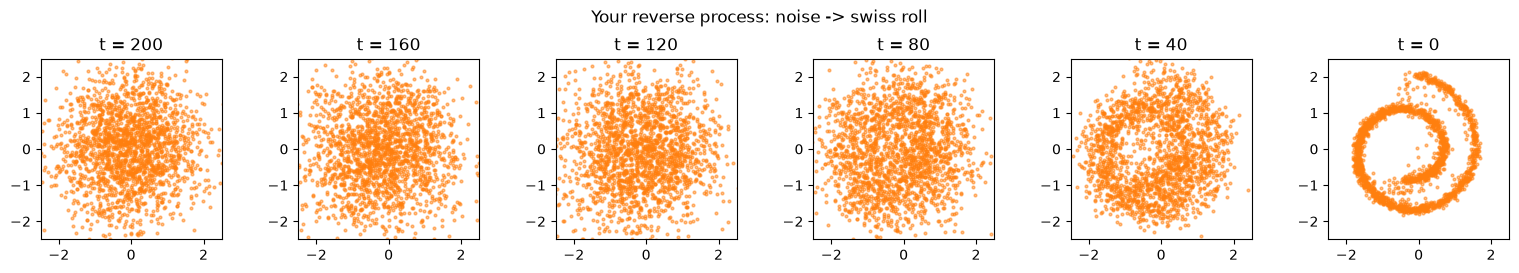

In [6]:
_, traj = my_ddpm_sample(model, schedule, (2000, 2), device, return_trajectory=True)
picks = [0, 40, 80, 120, 160, 200]
fig, axes = plt.subplots(1, len(picks), figsize=(2.6 * len(picks), 2.6))
for ax, i in zip(axes, picks):
    scatter_2d(ax, traj[i], f"t = {max(schedule.timesteps - i, 0)}", color="C1")
plt.suptitle("Your reverse process: noise -> swiss roll")
plt.tight_layout(); plt.show()

## 5. Watch the model's guess of $x_0$ sharpen

At every step the sampler is implicitly asking the model: *given where we are now,
what's your best guess of the final clean point?* Using $\varepsilon_\theta$ and the
inversion you built in notebook 01 (`recover_x0`):

$$\hat x_0=\frac{x_t-\sqrt{1-\bar\alpha_t}\,\varepsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}}.$$

Early in sampling (mostly noise) the guess is a vague blob; as $t\to0$ it sharpens
into a real sample. Implement `predict_x0` and watch it happen along the trajectory.

In [7]:
@torch.no_grad()
def predict_x0(model, x_t, t, schedule):
    '''The model's estimate of the clean x0 from a noised x_t at integer timestep t.'''
    tt = torch.full((x_t.shape[0],), t, device=x_t.device, dtype=torch.long)
    eps = model(x_t, tt)
    ab = schedule.alpha_bars[t]
    return (x_t - torch.sqrt(1 - ab) * eps) / torch.sqrt(ab)

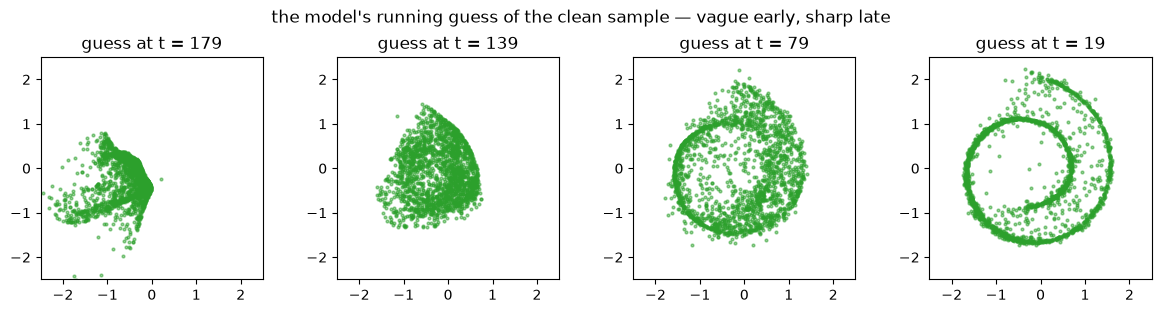

✅ done — the x0-guess sharpens as t decreases (this estimate is exactly what DDIM, nb 05, steps along)


In [8]:
# ---- self-check (x0 guess) ----
_, traj = my_ddpm_sample(model, schedule, (2000, 2), device, return_trajectory=True)
idxs = [20, 60, 120, 180]
fig, axes = plt.subplots(1, len(idxs), figsize=(3.0 * len(idxs), 3.0))
for ax, i in zip(axes, idxs):
    t = schedule.timesteps - 1 - i          # the timestep traj[i] sits at
    x0_hat = predict_x0(model, traj[i].to(device), t, schedule)
    assert x0_hat.shape == (2000, 2) and torch.isfinite(x0_hat).all()
    scatter_2d(ax, x0_hat, f"guess at t = {t}", color="C2")
plt.suptitle("the model's running guess of the clean sample — vague early, sharp late")
plt.tight_layout(); plt.show()
print("✅ done — the x0-guess sharpens as t decreases (this estimate is exactly what DDIM, nb 05, steps along)")

## 🎉 You built a diffusion model

Let's name what you derived and implemented:

| Piece | The idea |
|---|---|
| **Forward process** | shrink + add noise, variance preserved |
| **Nice property** | $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\varepsilon$ — jump to any $t$ in $O(1)$ |
| **ε-prediction** | knowing the noise ⟺ knowing the reverse mean |
| **Simple loss** | the ELBO collapses to plain MSE on $\varepsilon$ |
| **Ancestral sampler** | iterate the posterior mean + noise, from $x_T$ to $x_0$ |

Every ingredient of a modern image generator is here. What changes for real images
is mostly the **network** (U-Net instead of MLP) — the mathematics you just
derived stays the same.

**Part 2 next:** a minimal U-Net on MNIST, then DDIM for fast sampling and
classifier-free guidance for conditional generation.